### 必要库的引入

In [1]:
import os
import numpy as np
import math
import csv
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import warnings
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import Adam
import seaborn as sns
from scipy import integrate 

warnings.filterwarnings("ignore")
%matplotlib inline

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
torch.set_num_threads(1)

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

config = {
    'seed': 5201314,
    'select_all': True,
    'valid_ratio': 0.1,
    'n_epochs': 6000,         
    'batch_size': 3000,
    'learning_rate': 1e-5,
    'early_stop': 500,
    'save_path': './models/model_pure_data.pth' 
}

Using device: cuda


In [3]:
def same_seed(seed):
    '''Fixes random number generator seeds for reproducibility.'''
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
same_seed(config['seed'])

In [4]:
features = pd.read_csv('2026-02-04.csv') 
print('数据维度：', features.shape)
input_features_df = features.copy()

数据维度： (30000, 136)


In [5]:
from sklearn.model_selection import train_test_split

np.random.seed(config['seed'])
all_indices = np.arange(len(input_features_df))

train_indices, valid_indices = train_test_split(
    all_indices,
    test_size=config['valid_ratio'],
    random_state=config['seed'],
)

print("train_indices 长度:", len(train_indices))
print("valid_indices 长度:", len(valid_indices))

train_df = input_features_df.iloc[train_indices].reset_index(drop=True)
valid_df = input_features_df.iloc[valid_indices].reset_index(drop=True)

valid_df.to_csv("valid.csv", index=False)

train_data = train_df.values.astype(np.float32)
valid_data = valid_df.values.astype(np.float32)

train_indices 长度: 27000
valid_indices 长度: 3000


In [6]:
from sklearn.preprocessing import StandardScaler
import joblib 

def select_feat_and_normalize(train_data, valid_data, select_all=True):

    y_train_raw = train_data[:, -3:] 
    y_valid_raw = valid_data[:, -3:]
    
    raw_x_train = train_data[:, :-3]
    raw_x_valid = valid_data[:, :-3]

    if select_all:
        feat_idx = list(range(raw_x_train.shape[1]))
    else:

        feat_idx = [3, 4, 5] 

    x_train_sel = raw_x_train[:, feat_idx]
    x_valid_sel = raw_x_valid[:, feat_idx]
    
    scaler_x = StandardScaler()
    x_train_scaled = scaler_x.fit_transform(x_train_sel)
    x_valid_scaled = scaler_x.transform(x_valid_sel)
    
    print(f"特征处理完成: 维度 {x_train_scaled.shape[1]}")
    
    return x_train_scaled, x_valid_scaled, y_train_raw, y_valid_raw, scaler_x


x_train, x_valid, y_train, y_valid, scaler_x = select_feat_and_normalize(
    train_data, valid_data, config['select_all']
)

print("x_train shape:", x_train.shape) 
print("y_train shape:", y_train.shape) 

joblib.dump(scaler_x, 'scaler_x.pkl')

特征处理完成: 维度 133
=== 数据加载完成 (纯数据模式) ===
x_train shape: (27000, 133)
y_train shape: (27000, 3)


['scaler_x.pkl']

In [7]:
class GetDates(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.from_numpy(x).float()
        if y is not None:
            self.y = torch.from_numpy(y).float()
        else:
            self.y = None

    def __getitem__(self, idx):
        if self.y is not None:
            return self.x[idx], self.y[idx]
        else:
            return self.x[idx]

    def __len__(self):
        return len(self.x)

train_dataset = GetDates(x_train, y_train)
valid_dataset = GetDates(x_valid, y_valid)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=False, 
    drop_last=True,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
)

In [8]:
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(ResBlock, self).__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.act1 = nn.SiLU()
        
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.act2 = nn.SiLU()
        
        self.shortcut = nn.Sequential()
        if in_dim != out_dim:
            self.shortcut = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.act1(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out += residual  
        return self.act2(out)

class Advanced_TDTR_Net(nn.Module):
    def __init__(self, input_dim):
        super(Advanced_TDTR_Net, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256)
        )
        self.res_blocks = nn.Sequential(
            ResBlock(256, 256),
            ResBlock(256, 128),
            ResBlock(128, 64)  
        )
        
        self.head_itr1 = nn.Sequential(
            nn.Linear(64, 64), 
            nn.SiLU(),
            nn.Dropout(0.05),   
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)   
        )

        self.head_itr2 = nn.Sequential(
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Dropout(0.05),   
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)   
        )
        
        self.head_k = nn.Sequential(
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Dropout(0.05),  
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)   
        )

    def forward(self, x):
        feat = self.encoder(x)
        feat = self.res_blocks(feat)
        
        itr1_pred = self.head_itr1(feat)
        itr2_pred = self.head_itr2(feat)
        k_pred = self.head_k(feat)
        
        return torch.cat([itr1_pred, itr2_pred, k_pred], dim=1)

input_dim = x_train.shape[1]
print(f"Model Input Dimension: {input_dim}")
model = Advanced_TDTR_Net(input_dim=input_dim).to(device)

Model Input Dimension: 133


In [9]:
def trainer_pure_data(train_loader, valid_loader, model, config, device, train_losses, valid_losses):
    model_dir = os.path.dirname(config['save_path'])
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    data_loss_weights = torch.tensor([5.0, 10.0, 5.0], device=device)
    
    lr = config['learning_rate'] 
    n_epochs = config['n_epochs']              
    print(f"Start Pure Data Training (LR={lr})...")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_loss = math.inf
    early_stop_count = 0

    for epoch in range(n_epochs):
        model.train()
        train_loss_record = []
        
        for x_norm, y_raw in train_loader:
            x_norm, y_raw = x_norm.to(device), y_raw.to(device)
            optimizer.zero_grad()
            
            y_pred_raw = model(x_norm) 
            
            squared_diff = (y_pred_raw - y_raw) ** 2
            weighted_diff = squared_diff * data_loss_weights
            loss = torch.mean(weighted_diff)
            
            # Backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss_record.append(loss.item())

        mean_train_loss = sum(train_loss_record) / len(train_loss_record)
        
        # Validation
        model.eval()
        valid_loss_record = []
        with torch.no_grad():
            for x_norm, y_raw in valid_loader:
                x_norm, y_raw = x_norm.to(device), y_raw.to(device)
                pred = model(x_norm)
                # Validation Loss 也使用相同的加权
                w_loss = torch.mean(((pred - y_raw) ** 2) * data_loss_weights)
                valid_loss_record.append(w_loss.item())
        
        mean_valid_loss = sum(valid_loss_record) / len(valid_loss_record)
        
        train_losses.append(mean_train_loss)
        valid_losses.append(mean_valid_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Data_Train={mean_train_loss:.5f}, Data_Val={mean_valid_loss:.5f}")
            
        if mean_valid_loss < best_loss:
            best_loss = mean_valid_loss
            torch.save(model.state_dict(), config['save_path'])
            early_stop_count = 0
        else:
            early_stop_count += 1
        
        if early_stop_count >= config['early_stop']:
            print("Early Stopping Triggered.")
            break
            
    print(f"训练完成。最优模型已保存至 {config['save_path']}")

🚀 Start Pure Data Training (LR=1e-05)...
Epoch 0: Data_Train=41.93578, Data_Val=42.01476
Epoch 10: Data_Train=40.35159, Data_Val=40.35556
Epoch 20: Data_Train=38.20645, Data_Val=38.11370
Epoch 30: Data_Train=34.85351, Data_Val=34.69939
Epoch 40: Data_Train=30.33466, Data_Val=30.17481
Epoch 50: Data_Train=24.77535, Data_Val=24.69792
Epoch 60: Data_Train=18.84693, Data_Val=18.71875
Epoch 70: Data_Train=13.25613, Data_Val=13.11292
Epoch 80: Data_Train=8.25286, Data_Val=8.03644
Epoch 90: Data_Train=4.17364, Data_Val=3.95866
Epoch 100: Data_Train=1.85909, Data_Val=1.63266
Epoch 110: Data_Train=0.96566, Data_Val=0.82590
Epoch 120: Data_Train=0.68417, Data_Val=0.53871
Epoch 130: Data_Train=0.59926, Data_Val=0.43207
Epoch 140: Data_Train=0.56995, Data_Val=0.42788
Epoch 150: Data_Train=0.54319, Data_Val=0.38559
Epoch 160: Data_Train=0.52984, Data_Val=0.38113
Epoch 170: Data_Train=0.52196, Data_Val=0.37056
Epoch 180: Data_Train=0.51348, Data_Val=0.36353
Epoch 190: Data_Train=0.50483, Data_Val=0.

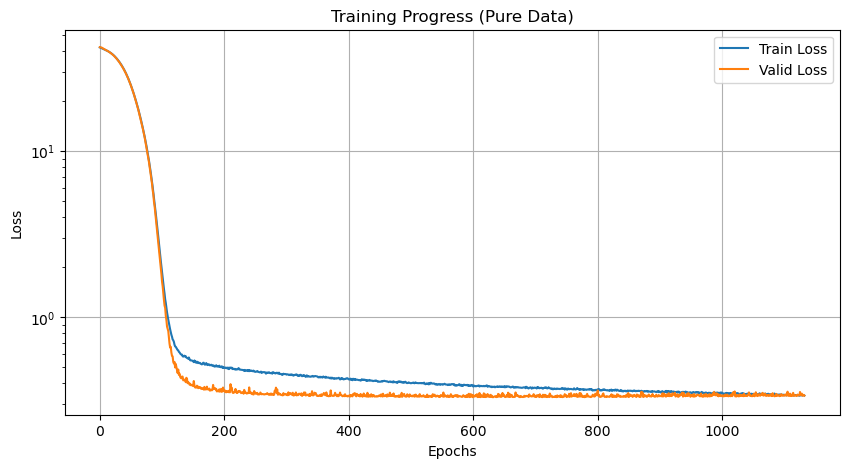

In [10]:
if not os.path.exists('./models'):
    os.makedirs('./models')

train_losses = []
valid_losses = []

input_dim = x_train.shape[1]
model = Advanced_TDTR_Net(input_dim=input_dim).to(device)

trainer_pure_data(
    train_loader, valid_loader, model, config, device, 
    train_losses, valid_losses
)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Progress (Pure Data)')
plt.legend()
plt.grid(True)
plt.yscale('log') 
plt.show()

In [11]:
def get_predictions(valid_loader, model, device):
    model.eval()     
    predictions = [] 
    targets = []     
    for x, y in valid_loader: 
        x, y = x.to(device), y.to(device) 
        with torch.no_grad(): 
            pred = model(x)   
        predictions.extend(pred.cpu().numpy()) 
        targets.extend(y.cpu().numpy()) 
    return predictions, targets    

✅ 模型加载完成。

📊 最终评估结果 (Pure Data Mode):
Target 0 (ITR+)   -> R2: 0.9481 | MSE: 0.033314
Target 1 (ITR-)   -> R2: 0.8777  | MSE: 0.079235
Target 2 (e_liquid) -> R2: 0.9669   | MSE: 0.006523
✅ Excel 文件已保存


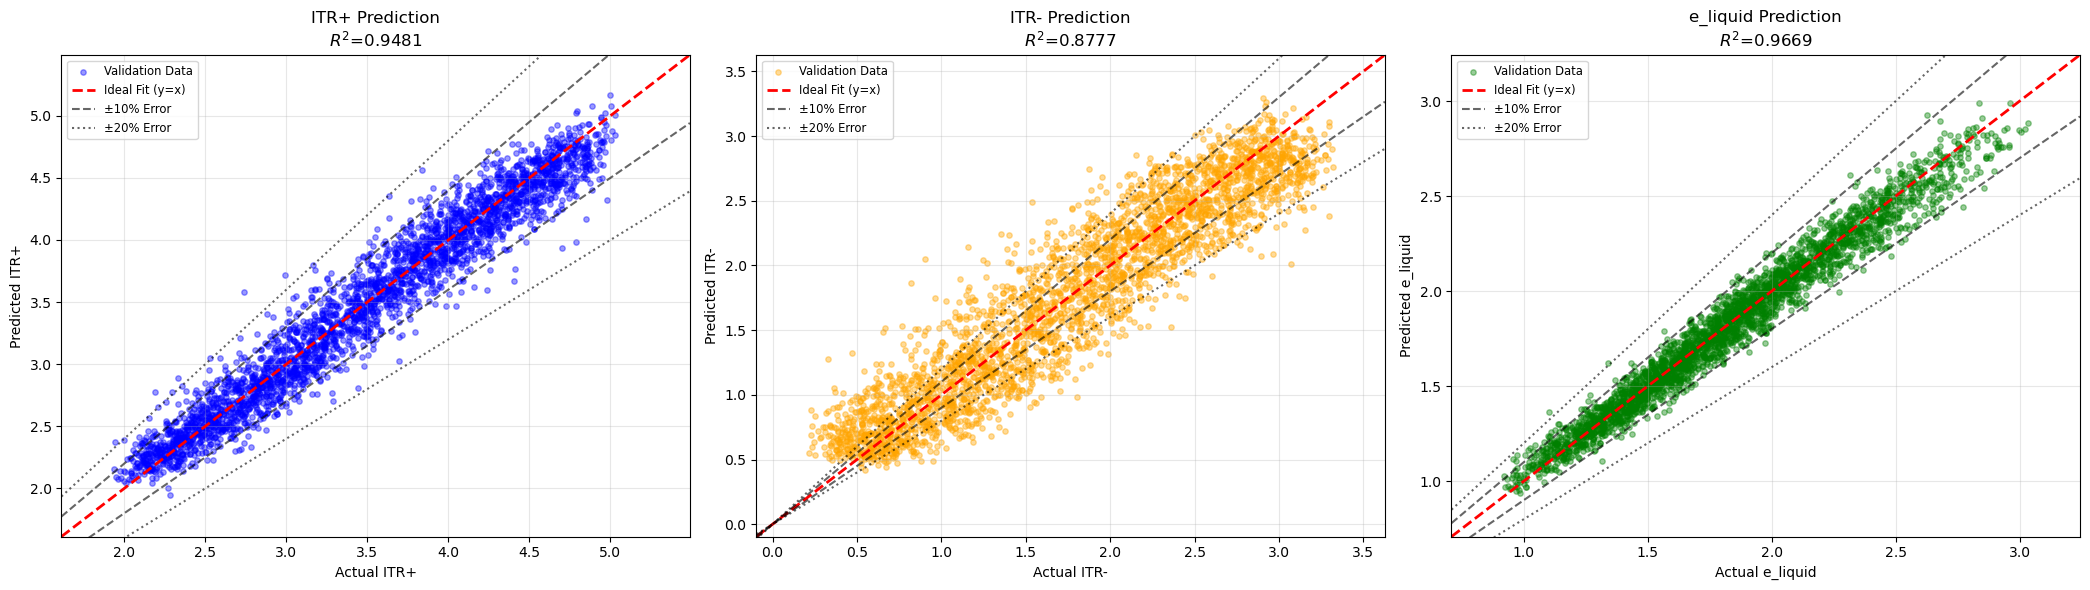

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import r2_score, mean_squared_error

def get_predictions_stack(loader, model, device):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            preds = model(x)
            
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())
            
    return np.vstack(all_preds), np.vstack(all_targets)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    input_dim = x_train.shape[1]
except NameError:
    print("x_train 未定义，请确保 input_dim 正确")

best_model = Advanced_TDTR_Net(input_dim=input_dim).to(device)

try:
    best_model.load_state_dict(torch.load(config['save_path'], map_location=device))
    print("模型加载完成。")
except Exception as e:
    print(f"模型加载失败: {e}")

best_model.eval()

predictions, targets = get_predictions_stack(valid_loader, best_model, device)

r2_itr = r2_score(targets[:, 0], predictions[:, 0])
mse_itr = mean_squared_error(targets[:, 0], predictions[:, 0])

r2_d2 = r2_score(targets[:, 1], predictions[:, 1])
mse_d2 = mean_squared_error(targets[:, 1], predictions[:, 1])

r2_k = r2_score(targets[:, 2], predictions[:, 2])
mse_k = mean_squared_error(targets[:, 2], predictions[:, 2])

print(f"\n 最终评估结果 (Pure Data Mode):")
print(f"Target 0 (ITR+)   -> R2: {r2_itr:.4f} | MSE: {mse_itr:.6f}")
print(f"Target 1 (ITR-)   -> R2: {r2_d2:.4f}  | MSE: {mse_d2:.6f}")
print(f"Target 2 (e_liquid) -> R2: {r2_k:.4f}   | MSE: {mse_k:.6f}")

# --- 4. 保存 Excel ---
target0_data = pd.DataFrame({'Actual': targets[:, 0], 'Predicted': predictions[:, 0]})
target1_data = pd.DataFrame({'Actual': targets[:, 1], 'Predicted': predictions[:, 1]})
target2_data = pd.DataFrame({'Actual': targets[:, 2], 'Predicted': predictions[:, 2]})

try:
    target0_data.to_excel('target0_ITR+.xlsx', index=False)
    target1_data.to_excel('target1_ITR-.xlsx', index=False)
    target2_data.to_excel('target2_e_liquid.xlsx', index=False)
    print(" Excel 文件已保存")
except ImportError:
    print(" 未安装 openpyxl，保存 CSV...")
    target0_data.to_csv('target0_ITR+.csv', index=False)
    target1_data.to_csv('target1_ITR-.csv', index=False)
    target2_data.to_csv('target2_e_liquid.csv', index=False)


fig, axs = plt.subplots(1, 3, figsize=(21, 6)) 

def plot_error_lines(ax, min_val, max_val):
    x_line = np.linspace(min_val, max_val, 100)
    
    ax.plot(x_line, x_line, 'r--', linewidth=2, label='Ideal Fit (y=x)')
    
    ax.plot(x_line, x_line * 1.1, 'k--', linewidth=1.5, alpha=0.6, label='±10% Error')
    ax.plot(x_line, x_line * 0.9, 'k--', linewidth=1.5, alpha=0.6)
    
    ax.plot(x_line, x_line * 1.2, 'k:', linewidth=1.5, alpha=0.6, label='±20% Error')
    ax.plot(x_line, x_line * 0.8, 'k:', linewidth=1.5, alpha=0.6)

plot_configs = [
    {
        'idx': 0, 'color': 'blue', 'title': f'ITR+ Prediction\n$R^2$={r2_itr:.4f}',
        'xlabel': 'Actual ITR+', 'ylabel': 'Predicted ITR+'
    },
    {
        'idx': 1, 'color': 'orange', 'title': f'ITR- Prediction\n$R^2$={r2_d2:.4f}',
        'xlabel': 'Actual ITR-', 'ylabel': 'Predicted ITR-'
    },
    {
        'idx': 2, 'color': 'green', 'title': f'e_liquid Prediction\n$R^2$={r2_k:.4f}',
        'xlabel': 'Actual e_liquid', 'ylabel': 'Predicted e_liquid'
    }
]

for config in plot_configs:
    i = config['idx']
    ax = axs[i]
    
    y_true = targets[:, i]
    y_pred = predictions[:, i]
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    
    padding = (max_val - min_val) * 0.1
    min_val -= padding
    max_val += padding
    
    ax.scatter(y_true, y_pred, color=config['color'], alpha=0.4, s=15, label='Validation Data')
    
    plot_error_lines(ax, min_val, max_val)
    
    ax.set_xlabel(config['xlabel'])
    ax.set_ylabel(config['ylabel'])
    ax.set_title(config['title'])
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    df_target0 = pd.read_excel('target0_ITR+.xlsx')
    actual_target0 = df_target0['Actual'].values 
    predicted_target0 = df_target0['Predicted'].values
except FileNotFoundError:
    df_target0 = pd.read_excel('target0.xlsx')
    actual_target0 = df_target0['Target0_Actual'].values
    predicted_target0 = df_target0['Target0_Predicted'].values

try:
    df_target1 = pd.read_excel('target1_ITR-.xlsx')
    actual_target1 = df_target1['Actual'].values
    predicted_target1 = df_target1['Predicted'].values
except FileNotFoundError:
    df_target1 = pd.read_excel('target1.xlsx')
    actual_target1 = df_target1['Target1_Actual'].values
    predicted_target1 = df_target1['Target1_Predicted'].values

try:
    df_target2 = pd.read_excel('target2_e_liquid.xlsx')
    actual_target2 = df_target2['Actual'].values
    predicted_target2 = df_target2['Predicted'].values
except FileNotFoundError:
    df_target2 = pd.read_excel('target2.xlsx')
    actual_target2 = df_target2['Target2_Actual'].values 
    predicted_target2 = df_target2['Target2_Predicted'].values


# Target 0 (ITR)
rmse_t0 = np.sqrt(mean_squared_error(actual_target0, predicted_target0))
mae_t0 = mean_absolute_error(actual_target0, predicted_target0)

# Target 1 (d2)
rmse_t1 = np.sqrt(mean_squared_error(actual_target1, predicted_target1))
mae_t1 = mean_absolute_error(actual_target1, predicted_target1)

# Target 2 (Ksub)
rmse_t2 = np.sqrt(mean_squared_error(actual_target2, predicted_target2))
mae_t2 = mean_absolute_error(actual_target2, predicted_target2)

print("="*50)
print(f"📊 Model Evaluation Metrics (3 Targets)")
print("-" * 50)
print(f"Target 0 (ITR+)  | RMSE: {rmse_t0:.4f} | MAE: {mae_t0:.4f}")
print(f"Target 1 (ITR-)   | RMSE: {rmse_t1:.4f} | MAE: {mae_t1:.4f}")
print(f"Target 2 (e_liquid) | RMSE: {rmse_t2:.4f} | MAE: {mae_t2:.4f}")
print("="*50)

📊 Model Evaluation Metrics (3 Targets)
--------------------------------------------------
✅ Target 0 (ITR+)  | RMSE: 0.1825 | MAE: 0.1420
✅ Target 1 (ITR-)   | RMSE: 0.2815 | MAE: 0.2258
✅ Target 2 (e_liquid) | RMSE: 0.0808 | MAE: 0.0633


In [14]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
import joblib 

config = {
    'batch_size': 5000,
    'model_path': './models/model_pure_data.pth', 
    'scaler_path': 'scaler_x.pkl'
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(ResBlock, self).__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.act1 = nn.SiLU()
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.act2 = nn.SiLU()
        self.shortcut = nn.Sequential()
        if in_dim != out_dim:
            self.shortcut = nn.Linear(in_dim, out_dim)
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.act1(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out += residual
        return self.act2(out)

class Advanced_TDTR_Net(nn.Module):
    def __init__(self, input_dim):
        super(Advanced_TDTR_Net, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256)
        )
        self.res_blocks = nn.Sequential(
            ResBlock(256, 256),
            ResBlock(256, 128),
            ResBlock(128, 64)  
        )
        
        self.head_itr1 = nn.Sequential(
            nn.Linear(64, 64), 
            nn.SiLU(),
            nn.Dropout(0.1),   
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)   
        )

        # ITR-2 专用头
        self.head_itr2 = nn.Sequential(
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Dropout(0.1),  
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)   
        )
        
        self.head_k = nn.Sequential(
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Dropout(0.1),   
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1) 
        )

    def forward(self, x):
        feat = self.encoder(x)
        feat = self.res_blocks(feat)
        
        # 分别预测
        itr1_pred = self.head_itr1(feat)
        itr2_pred = self.head_itr2(feat)
        k_pred = self.head_k(feat)
        
        return torch.cat([itr1_pred, itr2_pred, k_pred], dim=1)

if not os.path.exists(config['scaler_path']):
    raise FileNotFoundError("❌ 找不到 scaler_x.pkl")

print("正在加载预处理器...")
scaler = joblib.load(config['scaler_path'])
model_input_dim = scaler.n_features_in_
print(f"模型输入特征维度: {model_input_dim}")

file_path = 'kcl-2.csv' 
if not os.path.exists(file_path):
    print(f"找不到 {file_path}，生成随机数据演示...")
    raw_x_predict = np.random.rand(10, model_input_dim).astype(np.float32)
else:
    print(f"正在读取 {file_path} ...")
    df = pd.read_csv(file_path)
    raw_x_predict = df.values.astype(np.float32)

if raw_x_predict.shape[1] != model_input_dim:
    if raw_x_predict.shape[1] == model_input_dim + 2:
        print(f"输入多出2列 (可能是标签)，自动裁剪...")
        raw_x_predict = raw_x_predict[:, :-2]
    else:
        raise ValueError(f"维度错误：模型需要 {model_input_dim} 列，但输入有 {raw_x_predict.shape[1]} 列")

x_scaled = scaler.transform(raw_x_predict)

predict_dataset = TensorDataset(torch.from_numpy(x_scaled).float())
predict_loader = DataLoader(predict_dataset, batch_size=config['batch_size'], shuffle=False)

model = Advanced_TDTR_Net(input_dim=model_input_dim).to(device)
if os.path.exists(config['model_path']):
    model.load_state_dict(torch.load(config['model_path'], map_location=device))
    print("模型权重已加载。")
else:
    raise FileNotFoundError(f"找不到模型文件: {config['model_path']}")

model.eval()

all_preds = []
print("开始预测...")

with torch.no_grad():
    for batch in predict_loader:
        x_batch = batch[0].to(device)
        preds = model(x_batch)
        all_preds.extend(preds.cpu().numpy())

predictions = np.array(all_preds)


result_df = pd.DataFrame({
    'Pred_Total_ITR+': predictions[:, 0],
    'Pred_Total_ITR-': predictions[:, 1],
    'Pred_e_Liquid': predictions[:, 2]
})

print("\n预测结果预览:")
print(result_df.head())

output_filename = 'kcl-2-test_Prediction_Direct.csv'
result_df.to_csv(output_filename, index=False)
print(f"结果已保存为 '{output_filename}'")

Using device: cuda
正在加载预处理器...
模型输入特征维度: 133
正在读取 kcl-2.csv ...
✅ 模型权重已加载。
🚀 开始预测...

✅ 预测结果预览:
   Pred_Total_ITR+  Pred_Total_ITR-  Pred_e_Liquid
0         2.162045         0.882726       1.583485
💾 结果已保存为 'kcl-2-test_Prediction_Direct.csv'


In [15]:
import pandas as pd
import numpy as np

file_path = 'kcl-2.csv'
df = pd.read_csv(file_path)

def add_specific_noise(data, noise_config):
    data_copy = data.copy()
    
    for col, percent in noise_config.items():
        if col in data_copy.columns:
            std_dev = data_copy[col].abs() * percent
            
            noise = np.random.normal(loc=0, scale=std_dev, size=len(data_copy))
            
            data_copy[col] = data_copy[col] + noise
        else:
            print(f"警告: 列名 {col} 在数据中未找到，已跳过。")
            
    return data_copy

df_repeated = pd.concat([df]*10000, ignore_index=True)

noise_configuration = {
    'SiO2_K': 0.05,       
    'SiO2_cp': 0.025,      
    'Al_d*(10)': 0.05,    
    'Al_K*(100)': 0.05,   
    'Al_cp': 0.025,       
    'Rpump*(10)': 0.01,   
}

df_noisy = add_specific_noise(df_repeated, noise_configuration)

output_path = 'with_preb_variable_noise.csv'
df_noisy.to_csv(output_path, index=False)

print(f"处理完成，不同列已添加差异化扰动，保存至: {output_path}")

处理完成，不同列已添加差异化扰动，保存至: with_preb_variable_noise.csv


In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import os
import joblib 

config = {
    'batch_size': 5000,
    'model_path': './models/model_pure_data.pth', 
    'scaler_path': 'scaler_x.pkl',                
    'input_file': 'with_preb_variable_noise.csv', 
    'output_file': 'kcl-2-Final_Predictions_Only_Targets.csv' 
}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class ResBlock(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(ResBlock, self).__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.act1 = nn.SiLU()
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.act2 = nn.SiLU()
        self.shortcut = nn.Sequential()
        if in_dim != out_dim:
            self.shortcut = nn.Linear(in_dim, out_dim)
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.act1(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out += residual
        return self.act2(out)

class Advanced_TDTR_Net(nn.Module):
    def __init__(self, input_dim):
        super(Advanced_TDTR_Net, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256)
        )
        self.res_blocks = nn.Sequential(
            ResBlock(256, 256),
            ResBlock(256, 128),
            ResBlock(128, 64)  
        )
        
        self.head_itr1 = nn.Sequential(
            nn.Linear(64, 64), 
            nn.SiLU(),
            nn.Dropout(0.1),   
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)   
        )

        self.head_itr2 = nn.Sequential(
            nn.Linear(64, 64), 
            nn.SiLU(),
            nn.Dropout(0.1),   
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)  
        )
        
        self.head_k = nn.Sequential(
            nn.Linear(64, 64), 
            nn.SiLU(),
            nn.Dropout(0.1),   
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)   
        )

    def forward(self, x):
        feat = self.encoder(x)
        feat = self.res_blocks(feat)
        
        itr1_pred = self.head_itr1(feat)
        itr2_pred = self.head_itr2(feat)
        k_pred = self.head_k(feat)
        
        return torch.cat([itr1_pred, itr2_pred, k_pred], dim=1)

if not os.path.exists(config['input_file']):
    raise FileNotFoundError(f"找不到文件: {config['input_file']}")
df = pd.read_csv(config['input_file'])
raw_x = df.values.astype(np.float32)

scaler = joblib.load(config['scaler_path'])
input_dim = scaler.n_features_in_

if raw_x.shape[1] != input_dim:
    if raw_x.shape[1] == input_dim + 2:
        raw_x = raw_x[:, :-2]
    else:
        raise ValueError(f"维度不匹配！需要 {input_dim} 列，但输入有 {raw_x.shape[1]} 列。")

x_scaled = scaler.transform(raw_x)
loader = DataLoader(TensorDataset(torch.from_numpy(x_scaled).float()), 
                    batch_size=config['batch_size'], shuffle=False)

model = Advanced_TDTR_Net(input_dim=input_dim).to(device)
model.load_state_dict(torch.load(config['model_path'], map_location=device))
model.eval()

print("开始预测...")
all_preds = []
with torch.no_grad():
    for batch in loader:
        x_batch = batch[0].to(device)
        preds = model(x_batch)
        all_preds.extend(preds.cpu().numpy())

predictions = np.array(all_preds)

result_df = pd.DataFrame({
    'Pred_Total_ITR+': predictions[:, 0],
    'Pred_Total_ITR-': predictions[:, 1],
    'Pred_e_Liquid': predictions[:, 2]
})

result_df.to_csv(config['output_file'], index=False)

print("\n" + "="*50)
print(f"预测完成！")
print(f"结果已保存至: {config['output_file']}")
print("="*50)

print(result_df.head())

Using device: cuda
🚀 开始预测...

🎉 预测完成！
💾 纯净结果已保存至: kcl-2-Final_Predictions_Only_Targets.csv
   (仅包含 Pred_ITR_Total 和 Pred_K_Liquid 两列)
   Pred_Total_ITR+  Pred_Total_ITR-  Pred_e_Liquid
0         2.498116         1.211788       1.543553
1         2.147452         1.025188       1.478628
2         2.778493         1.192450       1.925048
3         2.135884         0.944022       1.332491
4         2.223367         1.004126       1.586811


📄 正在读取文件: kcl-2-Final_Predictions_Only_Targets.csv ...
✅ 成功读取列: ['ITR1', 'ITR2', 'k_liquid']


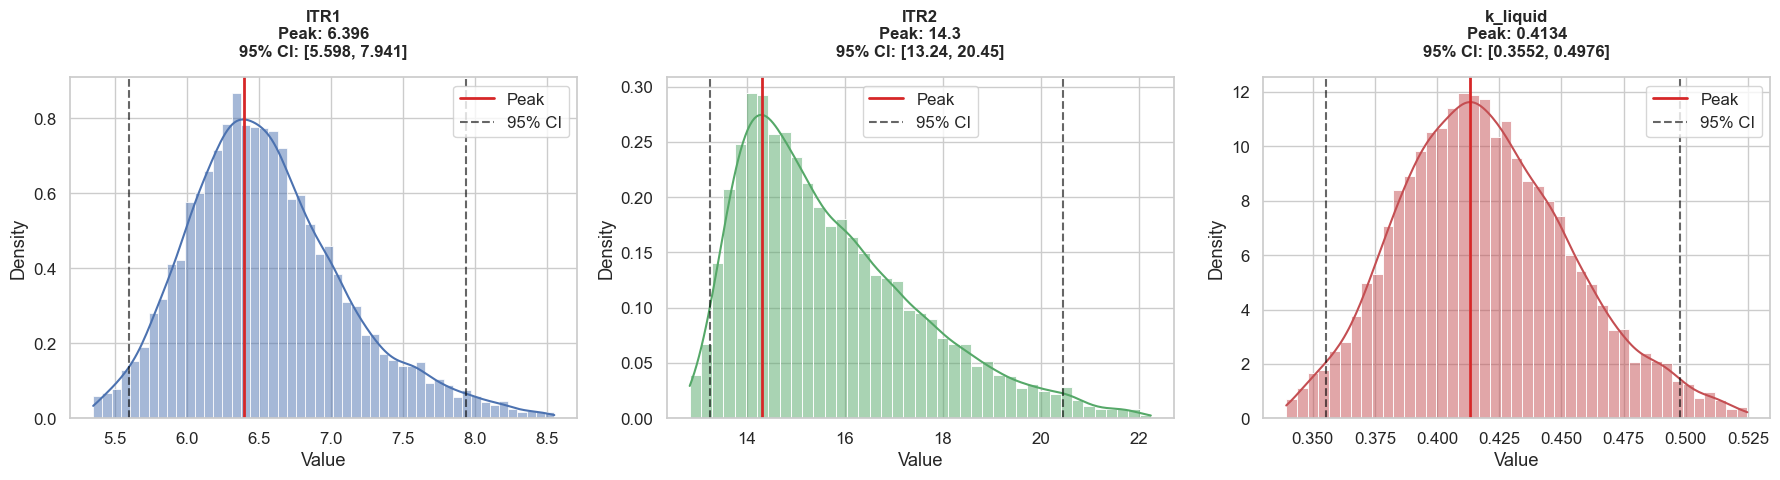


Parameter            | Peak (Highest Prob)  | Lower CI (2.5%)      | Upper CI (97.5%)    
--------------------------------------------------------------------------------
ITR1                 | 6.39583              | 5.59812              | 7.94146             
ITR2                 | 14.2983              | 13.242               | 20.4537             
k_liquid             | 0.413398             | 0.355198             | 0.497626            


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.close('all')

file_path = 'kcl-2-Final_Predictions_Only_Targets.csv'

try:
    print(f"正在读取文件: {file_path} ...")
    df = pd.read_csv(file_path)
    

    data_cols = df.iloc[:, 0:3] 
    col_names = data_cols.columns.tolist() 
    print(f"成功读取列: {col_names}")

    data_cols.replace([np.inf, -np.inf], np.nan, inplace=True)
    data_cols.dropna(inplace=True)

except FileNotFoundError:
    print(f"错误: 找不到文件 {file_path}")
    np.random.seed(42)
    df = pd.DataFrame({
        'ITR1': np.random.normal(50, 5, 2000),
        'ITR2': np.random.normal(0.5, 0.05, 2000),
        'k_liquid': np.random.normal(0.33, 0.02, 2000)
    })
    data_cols = df
    col_names = df.columns.tolist()


def get_stats(data):
    ci_low = np.percentile(data, 2.5)
    ci_high = np.percentile(data, 97.5)
    
    kde = gaussian_kde(data)
    grid = np.linspace(data.min(), data.max(), 5000) 
    density = kde(grid)
    peak_val = grid[np.argmax(density)]
    
    return peak_val, ci_low, ci_high

sns.set_theme(style="whitegrid", font_scale=1.1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results = [] 

colors = ['#4c72b0', '#55a868', '#c44e52'] 

for i, col in enumerate(col_names):
    data = data_cols[col].values
    
    limit_low = np.percentile(data, 0.5)
    limit_high = np.percentile(data, 99.5)
    plot_data = data[(data >= limit_low) & (data <= limit_high)]
    
    peak, low, high = get_stats(data)
    results.append((col, peak, low, high))
    
    ax = axes[i]
    color = colors[i % len(colors)]
    
    sns.histplot(plot_data, kde=True, ax=ax, color=color, alpha=0.5, stat='density')
    
    ax.axvline(peak, color='#d62728', linestyle='-', linewidth=2, label='Peak')

    ax.axvline(low, color='black', linestyle='--', alpha=0.6, linewidth=1.5, label='95% CI')
    ax.axvline(high, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
    
    title_text = f"{col}\nPeak: {peak:.4g}\n95% CI: [{low:.4g}, {high:.4g}]"
    ax.set_title(title_text, fontsize=12, pad=15, fontweight='bold')
    
    ax.set_xlabel('Value')
    ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print(f"{'Parameter':<20} | {'Peak (Highest Prob)':<20} | {'Lower CI (2.5%)':<20} | {'Upper CI (97.5%)':<20}")
print("-" * 80)
for res in results:
    name, p, l, h = res
    print(f"{name:<20} | {p:<20.6g} | {l:<20.6g} | {h:<20.6g}")
print("=" * 80)